In [1]:
%load_ext autoreload
%autoreload 2

In [74]:
import sys

sys.path.append("../src")

import cv2
import numpy as np
from rescue import utils, img_match
from PIL import Image
import matplotlib.pyplot as plt

In [8]:
naip_path = "../data/disaster_city.nc"
recon_path = "../generated/for_slides.glb"
img_sat = Image.fromarray(utils.get_png_from_naip(naip_path))

superglue_matcher = img_match.SuperGlueMatcher()


Loading weights: 100%|██████████| 363/363 [00:00<00:00, 7770.16it/s]


In [84]:
render_3d, depth = utils.render_3d_plot_from_above(recon_path=recon_path, bg_color=[0, 0, 0, 0])

img_3d = Image.fromarray(render_3d)
imgs_rotated = {x: img_3d.rotate(x) for x in [0, 90, 180, 270]}

Found num geometries: 28


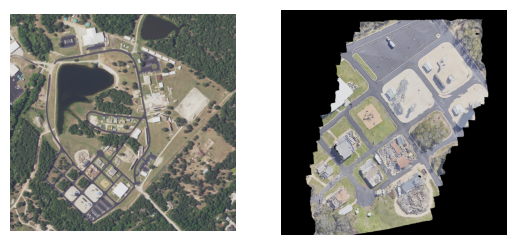

In [85]:
fig, axes = plt.subplots(nrows=1, ncols=2)

axes[0].imshow(img_sat)
axes[1].imshow(img_3d)
[ax.axis("off") for ax in axes];

In [86]:
matches = {}

for rot, img in imgs_rotated.items():
    matches[rot] = superglue_matcher.match(img_sat, img)[0]
    print(f"num mactches for {rot} matches: {len(matches[rot]['matching_scores'])}")

num mactches for 0 matches: 1
num mactches for 90 matches: 2
num mactches for 180 matches: 21
num mactches for 270 matches: 0


In [87]:
best_rot, best_matches = max(matches.items(), key=lambda x: len(x[1]['matching_scores']))

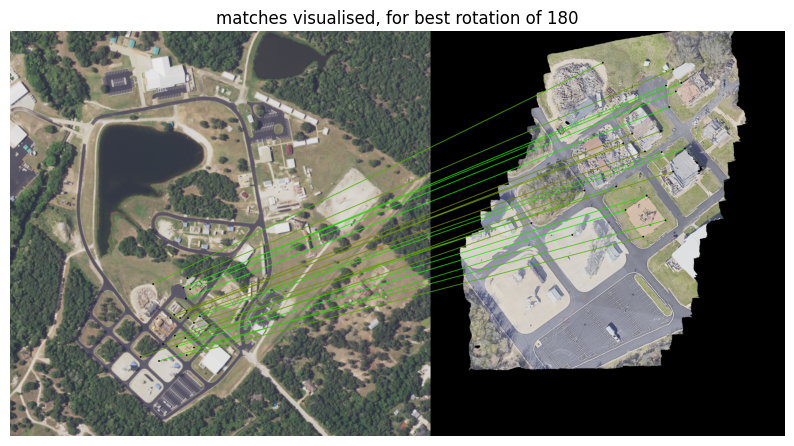

In [88]:
vis_matches = superglue_matcher.plot_samples(processed_outputs=[best_matches], imgs = [img_sat, imgs_rotated[best_rot]])[0]
plt.figure(figsize = (10, 10))
plt.axis('off')
plt.imshow(vis_matches)
plt.title(f'matches visualised, for best rotation of {best_rot}');

In [125]:
aligned, H, mask = img_match.align_images_after_superglue(img_sat, imgs_rotated[best_rot], best_matches)


num inliers: [12]


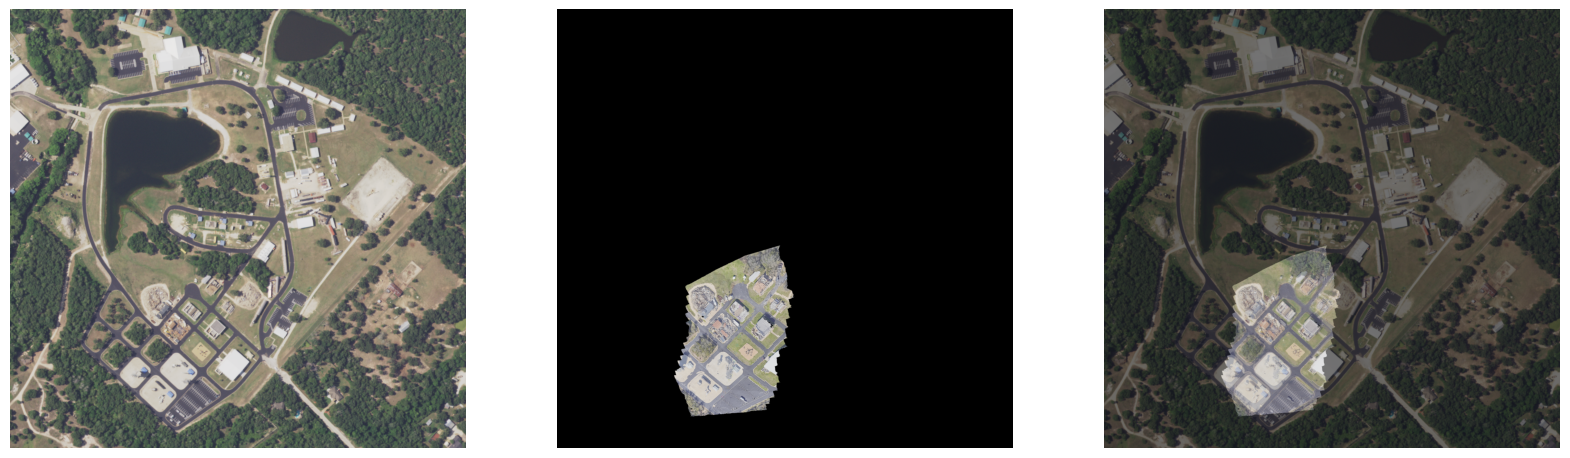

In [126]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 10))

axes[0].imshow(img_sat)
axes[1].imshow(aligned)
axes[2].imshow(img_sat)
axes[2].imshow(aligned, alpha = 0.5)

[ax.axis('off') for ax in axes];